## CURATING DATASET

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import datetime as dt

# 2024-01-01 to 2026-01-01
df = pl.read_csv("SA-24-26.csv", try_parse_dates=True)

In [2]:
""""

Data obtained from {

    AEMO - RRP, TOTALDEMAND

    othersources explain where obtained ...

    (maybe include links also???)

}

dataset comes with {

    "SETTLEMENTDATE", "RRP", "TOTALDEMAND", "gen_solar_rooftop", "gen_solar_utility", "gen_wind", 
    "gen_battery_discharging", "gen_battery_charging", "gen_gas", "gen_imports",  "temperature", 
    "humidity", "wind_speed", "wind_direction", "solar_radiation", "cloud_cover"

}

"""""

'"\n\nData obtained from {\n\n    AEMO - RRP, TOTALDEMAND\n\n    othersources explain where obtained ...\n\n    (maybe include links also???)\n\n}\n\ndataset comes with {\n\n    "SETTLEMENTDATE", "RRP", "TOTALDEMAND", "gen_solar_rooftop", "gen_solar_utility", "gen_wind", \n    "gen_battery_discharging", "gen_battery_charging", "gen_gas", "gen_imports",  "temperature", \n    "humidity", "wind_speed", "wind_direction", "solar_radiation", "cloud_cover"\n\n}\n\n'

In [3]:
df = df.with_columns([
    # total available intermittent renewables
    (pl.col("gen_solar_rooftop") + pl.col("gen_solar_utility") + pl.col("gen_wind")).alias("total_renewables"),
]).with_columns([
    # net Demand
    (pl.col("TOTALDEMAND") - pl.col("total_renewables")).alias("net_demand"),
    # renewable fraction (clamped to avoid dividing by zero if demand is weird)
    (pl.col("total_renewables") / pl.col("TOTALDEMAND").clip(lower_bound=1)).alias("renewable_share")
]).with_columns([
    # positive means discharging to grid, negative means charging (absorbing grid load)
    (pl.col("gen_battery_discharging") - pl.col("gen_battery_charging")).alias("net_battery_generation"),
    (pl.col("net_demand") * pl.col("temperature")).alias("net_demand_thermal_load")
])

In [4]:
predictors = [
    "RRP", "TOTALDEMAND", "gen_solar_rooftop", "gen_solar_utility", "gen_wind", 
    "gen_battery_discharging", "gen_battery_charging", "gen_gas", "gen_imports", 
    "temperature", "humidity", "wind_speed", "wind_direction", 
    "solar_radiation", "cloud_cover", "total_renewables", "net_demand", "renewable_share",
    "net_battery_generation", "net_demand_thermal_load"
]

window_sizes = [3, 5, 10, 20, 50, 100, 200]

# link is_price_positive to how log returns calculated
# essentially forces all log returns to be positive, so model views is_price_positive feature to determine direction
df = df.with_columns([

    pl.when(pl.col("RRP") >= 0).then(1).otherwise(0).alias("is_price_positive"),
    
    # absolute log return regime
    (
        pl.when(pl.col("RRP").abs() < 0.1)
        .then(0.1)
        .otherwise(pl.col("RRP").abs())
        .log()
        .diff()
    ).alias("log_return"),
    
    #  standard returns
    pl.col("RRP").diff().alias("return"),
    pl.col("RRP").shift(1).alias("price_lag1"),
    pl.col("RRP").shift(2).alias("price_lag2"),
    pl.col("RRP").shift(3).alias("price_lag3"),
    pl.col("RRP").shift(4).alias("price_lag4"),
    pl.col("RRP").shift(5).alias("price_lag5"),

    pl.col("TOTALDEMAND").shift(1).alias("demand_lag1"),
    pl.col("TOTALDEMAND").shift(2).alias("demand_lag2"),
    pl.col("TOTALDEMAND").shift(3).alias("demand_lag3"),
    pl.col("TOTALDEMAND").shift(4).alias("demand_lag4"),
    pl.col("TOTALDEMAND").shift(5).alias("demand_lag5"),

    pl.col("RRP").diff().alias("change_rrp")

])


rolling_expressions = []

# volatility windows for RRP, log_return, return
for w in [3, 5, 10, 20, 50]:
    rolling_expressions.append(pl.col("RRP").rolling_std(window_size=w).alias(f"RRP_volatility_{w}"))
    rolling_expressions.append(pl.col("log_return").rolling_std(window_size=w).alias(f"log_volatility_{w}"))
    rolling_expressions.append(pl.col("return").rolling_std(window_size=w).alias(f"volatility_{w}"))


# rolling trend feature
for pred in predictors:
    for w in window_sizes:
        # standardising naming structure
        rolling_expressions.append(
            pl.col(pred).rolling_mean(window_size=w).alias(f"{pred}_trend_{w}")
        )

df = df.with_columns(rolling_expressions)

In [5]:

df = df.with_columns([

    pl.col("SETTLEMENTDATE").dt.hour().alias("hour"),
    pl.col("SETTLEMENTDATE").dt.weekday().alias("weekday"),
    # checking if weekend
    pl.col("SETTLEMENTDATE").dt.weekday().is_in([6, 7]).cast(pl.Int8).alias("is_weekend")

]).with_columns([

    # sine/cosine encoding for smooth hour transitions
    (pl.col("hour") * (2 * np.pi / 24)).sin().alias("hour_sin"),
    (pl.col("hour") * (2 * np.pi / 24)).cos().alias("hour_cos"),
    (pl.col("weekday") * (2 * np.pi / 24)).cos().alias("weekday_sin"),
    (pl.col("weekday") * (2 * np.pi / 24)).cos().alias("weekday_cos")

]).with_columns([
    pl.col("RRP").shift(-1).alias("target_next_RRP") # this is what we want to predict
])

# need to drop the very last row of the dataset because it won't have a next price
df = df.drop_nulls(subset=["target_next_RRP"])

In [6]:
df.write_csv("Electricity_SA-24-26.csv")
print(f"Feature engineering completed. Shape of dataset: {df.shape}")

Feature engineering completed. Shape of dataset: (35039, 217)


In [7]:
y = df["target_next_RRP"].to_numpy()

# not required/parsible for predicting model
X_df = df.drop([
    "SETTLEMENTDATE",
    "hour",
    "weekday",
    "target_next_RRP"
])

feature_cols = X_df.columns

X = X_df.to_numpy()

## BASIC STATISTICAL ANALYSIS

##### General overview

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import spearmanr, norm
import datetime as dt
from sklearn.mixture import GaussianMixture

In [9]:
# average and standard deviation of price
print(f"Mean RRP: {df["RRP"].mean()}, RRP Standard Deviation: {df["RRP"].std()} ")

Mean RRP: 75.53049145238164, RRP Standard Deviation: 32.776058228792785 


In [10]:
# overview of price per timestamp (half hour)
print(df["RRP"].describe())

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 35039.0   │
│ null_count ┆ 0.0       │
│ mean       ┆ 75.530491 │
│ std        ┆ 32.776058 │
│ min        ┆ -51.8     │
│ 25%        ┆ 53.43     │
│ 50%        ┆ 75.81     │
│ 75%        ┆ 97.86     │
│ max        ┆ 205.94    │
└────────────┴───────────┘


In [11]:
# RRP going negative
neg = [rrp for rrp in df["RRP"] if rrp < 0]
print(f"Percentage of negative RRP values: {len(neg) / len(df['RRP']) * 100:.5f}%")

Percentage of negative RRP values: 1.14159%


In [12]:
monthly_negatives = (
    df.group_by("month")
    .agg(
        ((pl.col("RRP") < 0).sum() / pl.col("RRP").count() * 100).alias("Percentage Of Negative Timestamps")
    )
    .sort("month")
)

with pl.Config(tbl_rows=-1):
    print(monthly_negatives)

shape: (12, 2)
┌───────┬─────────────────────────────────┐
│ month ┆ Percentage Of Negative Timesta… │
│ ---   ┆ ---                             │
│ i64   ┆ f64                             │
╞═══════╪═════════════════════════════════╡
│ 1     ┆ 0.772849                        │
│ 2     ┆ 0.950292                        │
│ 3     ┆ 1.377688                        │
│ 4     ┆ 1.10957                         │
│ 5     ┆ 1.276882                        │
│ 6     ┆ 1.25                            │
│ 7     ┆ 1.71371                         │
│ 8     ┆ 1.176075                        │
│ 9     ┆ 1.145833                        │
│ 10    ┆ 1.076716                        │
│ 11    ┆ 0.9375                          │
│ 12    ┆ 0.888282                        │
└───────┴─────────────────────────────────┘


(array([19723., 19814., 19905., 19997., 20089., 20179., 20270., 20362.,
        20454.]),
 [Text(19723.0, 0, '2024-01'),
  Text(19814.0, 0, '2024-04'),
  Text(19905.0, 0, '2024-07'),
  Text(19997.0, 0, '2024-10'),
  Text(20089.0, 0, '2025-01'),
  Text(20179.0, 0, '2025-04'),
  Text(20270.0, 0, '2025-07'),
  Text(20362.0, 0, '2025-10'),
  Text(20454.0, 0, '2026-01')])

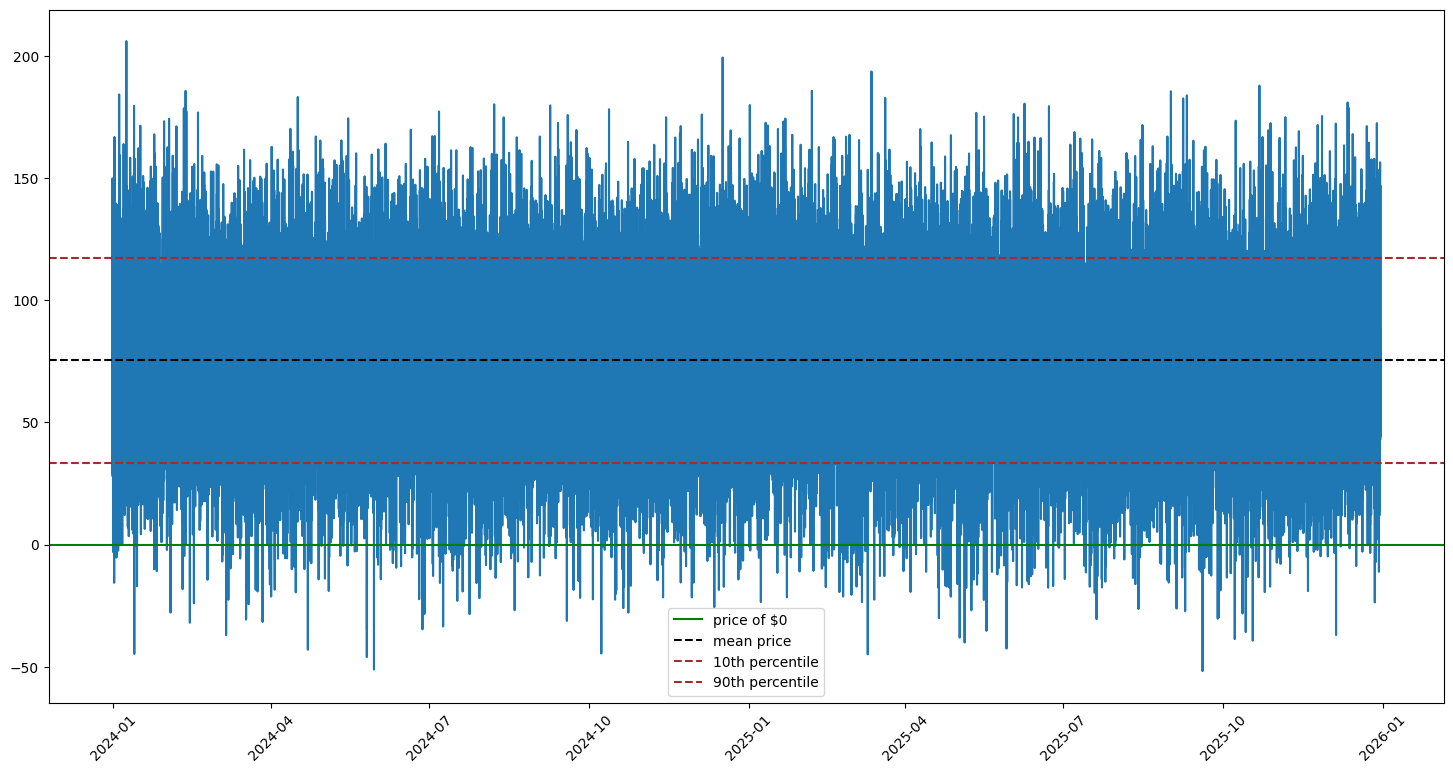

In [13]:
plt.figure(figsize=(18, 9))
plt.plot(df["SETTLEMENTDATE"], df["RRP"])
plt.axhline(y = 0, color = 'green', linestyle = '-', label = "price of $0")
plt.axhline(y = df["RRP"].mean(), color = 'black', linestyle = '--', label = "mean price")
plt.axhline(y = df["RRP"].quantile(0.1), color = 'brown', linestyle = '--', label = "10th percentile")
plt.axhline(y = df["RRP"].quantile(0.9), color = 'brown', linestyle = '--', label = "90th percentile")
plt.legend()
plt.xticks(rotation=45)

##### Curious about how strong demand is as a predictor of price, so we train a simple model to determine its predictive power

In [14]:
df = (df
    .with_columns((pl.col("TOTALDEMAND") ** 2).alias("TOTALDEMAND_SQ"))
    .with_columns((pl.col("TOTALDEMAND") ** 3).alias("TOTALDEMAND_CUBE"))
)

rrp_demand_model = smf.ols('RRP ~ TOTALDEMAND + TOTALDEMAND_SQ + TOTALDEMAND_CUBE', data=df).fit()
rrp_demand_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    RRP   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     318.2
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          7.78e-204
Time:                        12:25:40   Log-Likelihood:            -1.7152e+05
No. Observations:               35039   AIC:                         3.431e+05
Df Residuals:                   35035   BIC:                         3.431e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         -491.6817     31.428    -15.645      0.000    -553.282    -430.082
TOTALDEMAND          0.9181      0.051     18.119      0.000       0.819       1.017
TOTALDEMAND_SQ      -0.0005   2.69e-05    -17.843      0.000      -0.001      -0.000
TOTALDEMAND_CUBE  8.066e-08   4.68e-09     17.235      0.000    7.15e-08    8.98e-08
==============================================================================
Omnibus:                        4.558   Durbin-Watson:                   1.952
Prob(Omnibus):                  0.102   Jarque-Bera (JB):                4.510
Skew:                          -0.018   Prob(JB):                        0.105
Kurtosis:                       2.958   Cond. No.                     1.36e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.36e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

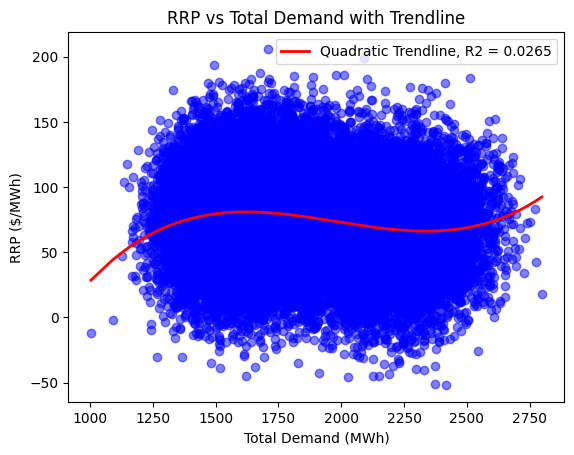

In [15]:
sorted_demand = (
    df.select("TOTALDEMAND")
    .sort("TOTALDEMAND")
    .with_columns((pl.col("TOTALDEMAND") ** 2).alias("TOTALDEMAND_SQ"))
    .with_columns((pl.col("TOTALDEMAND") ** 3).alias("TOTALDEMAND_CUBE"))
)

predicted_rrp = rrp_demand_model.predict(sorted_demand.to_pandas())

plt.scatter(df["TOTALDEMAND"].to_pandas(), df["RRP"].to_pandas(), alpha=0.5, color="blue")
plt.plot(sorted_demand["TOTALDEMAND"].to_pandas(), predicted_rrp, color="red", linewidth=2, label=f"Quadratic Trendline, R2 = {rrp_demand_model.rsquared:.4f}")
plt.xlabel("Total Demand (MWh)")
plt.ylabel("RRP ($/MWh)")
plt.title("RRP vs Total Demand with Trendline")
plt.legend()

In [16]:
correlation, p_value = stats.spearmanr(df["RRP"], df["TOTALDEMAND"])

print(f"The correlation between demand and price: {correlation}, p-value: {p_value}. ")

The correlation between demand and price: -0.11059543861679706, p-value: 8.968617334620691e-96. 


Interestingly we see a negative correlation between demand and rrp. And note that their relationship can be described as statistically significant evidenced by the low p value (although demand is still not a strong predicitor of price itself). 

##### Analysing distributions of price

Text(0.5, 1.0, 'RRP Distibtution')

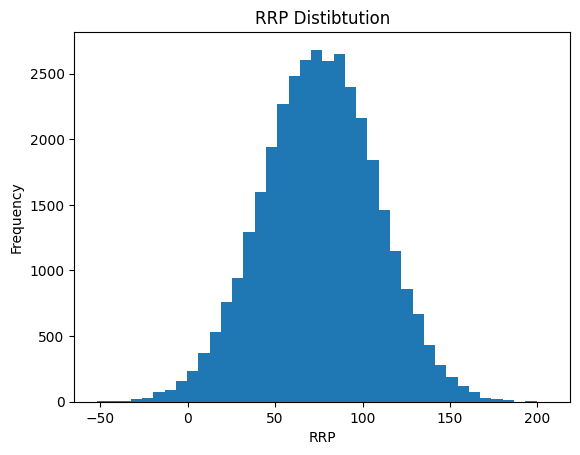

In [17]:
plt.hist(df["RRP"], bins=40)
plt.xlabel("RRP")
plt.ylabel("Frequency")
plt.title("RRP Distibtution")

There are several things to note from considering the distribution of prices

- Mean of ~ $75
- Distribution is right skewed
- Left tail is much shallower then right tail which is fatter
- Negative prices are wiithin the distribution, and account for ~ 1.5% of prices of all timestamps in dataset

These factors mean a traditional distribution which has intepretability does not fit well to this distribution. Hence a regime based model will be created of which each respective regime has a differing distribution of prices. A Gaussian Mixture Model (GMM), and similar approaches could be used to fit this distribution, however much greater intepretability and understanding of market dynamics is gained through a regime based approach instead. 

##### Markov Variance Switching Model (significant improvement from Gaussian HMM which cannot adequitely model price regimes)

Since clearly the regimes and overall price distribution are non-gaussian, a gaussian hidden markov model does not provide a reliable regime distribution. A markov variance switiching model deals much better with the asymetry and fat tails in the distribution. 

In [18]:
import seaborn as sns
import statsmodels.api as sm  

df_clean = df.drop_nulls(subset=["RRP"])
rrp_series_30min = df_clean["RRP"].to_numpy()


model_30min = sm.tsa.MarkovRegression(
    endog=rrp_series_30min, 
    k_regimes=3, 
    trend='c', 
    switching_variance=True
)

results_30min = model_30min.fit(method='ncg', search_reps=50)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
smoothed_probs = results_30min.smoothed_marginal_probabilities
hidden_states = np.argmax(smoothed_probs, axis=1)

In [20]:
state_variances = []
for s in range(3):
    mask = (hidden_states == s)
    num_obs = np.sum(mask)
    if num_obs > 1:
        state_variances.append((s, rrp_series_30min[mask].var()))
    else:
        state_variances.append((s, -1.0))
state_order = [state for state, var in sorted(state_variances, key=lambda x: x[1])]

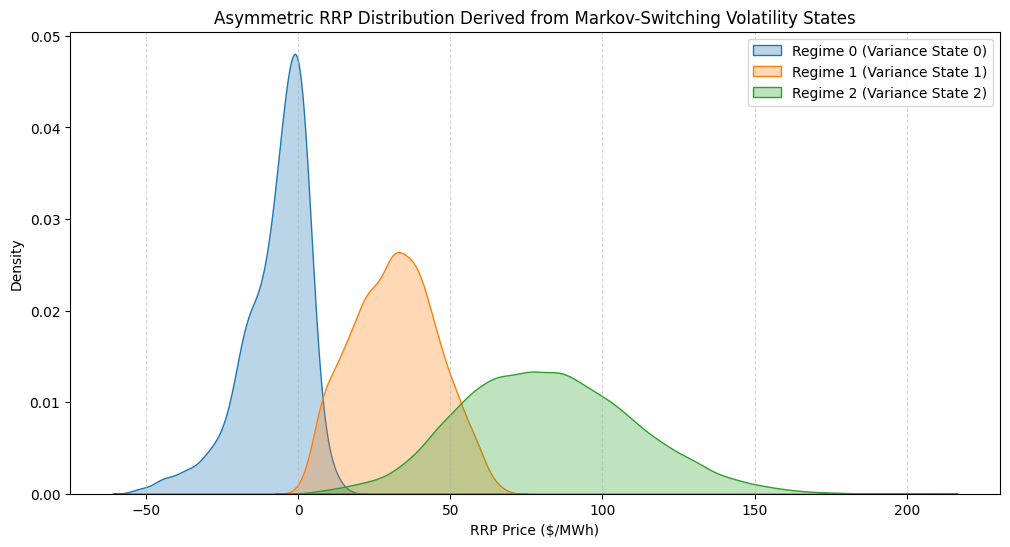

In [21]:
plt.figure(figsize=(12, 6))

for i, state in enumerate(state_order):
    mask = (hidden_states == state)
    
    sns.kdeplot(
            rrp_series_30min[mask], 
            label=f"Regime {i} (Variance State {state})", 
            fill=True, 
            alpha=0.3,
            warn_singular=False
        )
        

plt.title("Asymmetric RRP Distribution Derived from Markov-Switching Volatility States")
plt.xlabel("RRP Price ($/MWh)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)

In [22]:
results_30min.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Markov Switching Model Results                        
==============================================================================
Dep. Variable:                      y   No. Observations:                35039
Model:               MarkovRegression   Log Likelihood             -171923.059
Date:                Wed, 01 Jul 2026   AIC                         343870.117
Time:                        12:31:30   BIC                         343971.688
Sample:                             0   HQIC                        343902.468
                              - 35039                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.8237        nan        nan        nan         nan         nan
sigma2       354.6937     22.272     15.926      0.000     311.042     398.346
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.2210      2.212     22.704      0.000      45.886      54.556
sigma2       508.0094     51.762      9.814      0.000     406.558     609.461
                             Regime 2 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         83.5625        nan        nan        nan         nan         nan
sigma2       880.8651        nan        nan        nan         nan         nan
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.0816      0.021      3.835      0.000       0.040       0.123
p[1->0]        0.0251      0.005      5.191      0.000       0.016       0.035
p[2->0]        0.0186        nan        nan        nan         nan         nan
p[0->1]        0.3246      0.064      5.108      0.000       0.200       0.449
p[1->1]        0.4083      0.045      9.054      0.000       0.320       0.497
p[2->1]        0.1407        nan        nan        nan         nan         nan
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

In [23]:
# code

In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor

exclude_cols = ["SETTLEMENTDATE", "target_next_RRP"]

feature_names = [col for col in df_clean.columns if col not in exclude_cols]

X = df_clean.select(feature_names).to_numpy()
y = df_clean["target_next_RRP"].to_numpy()

# using filtered_marginal_probabilities to avoid look ahead bias
regimes = np.argmax(results_30min.filtered_marginal_probabilities, axis=1)

# 80, 20 train, test split
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
regimes_train, regimes_test = regimes[:train_size], regimes[train_size:]

regime_models = {}
unique_regimes = np.unique(regimes_train)

# training specific models for each identified regime
for r in unique_regimes:
    mask_r = (regimes_train == r)
    X_train_r = X_train[mask_r]
    y_train_r = y_train[mask_r]
    
    if len(y_train_r) < 20:
        continue
        
    model = HistGradientBoostingRegressor(random_state=42, max_iter=100)
    model.fit(X_train_r, y_train_r)
    regime_models[r] = model


In [25]:
from sklearn.inspection import permutation_importance

def interpret_regime_experts(regime_models, X_train, y_train, regimes_train, feature_names, top_n=5):

    # computes and prints the top permutation feature importances for each specialized regime expert model.
    for r, model in regime_models.items():
        # Mask arrays to match this specific regime slice
        mask_r = (regimes_train == r)
        X_train_r = X_train[mask_r]
        y_train_r = y_train[mask_r]
            
        # calculating permutation importance
        result = permutation_importance(
            model, X_train_r, y_train_r, 
            n_repeats=5, # 5 shuffles per feature
            random_state=42,
            n_jobs=-1  # use all cpu cores for speed - not relevant to model itself
        )
        
        # sorting features by highest mean performance drop
        importances = result.importances_mean
        sorted_indices = np.argsort(importances)[::-1][:top_n]
        
        print(f"[Regime {r} Model] Top {top_n} Predictors:")
        print("-" * 55)
        print(f"{'Rank':<5} | {'Feature Name':<32} | {'Importance Score':<12}")
        print("-" * 55)
        
        for rank, idx in enumerate(sorted_indices, 1):
            score = importances[idx]
            print(f"#{rank:<4} | {feature_names[idx]:<32} | {score:.5f}")
            



In [26]:

interpret_regime_experts(
    regime_models=regime_models,
    X_train=X_train,
    y_train=y_train,
    regimes_train=regimes_train,
    feature_names=feature_names,
    top_n=5
)

[Regime 0 Model] Top 5 Predictors:
-------------------------------------------------------
Rank  | Feature Name                     | Importance Score
-------------------------------------------------------
#1    | gen_battery_discharging_trend_50 | 0.03983
#2    | net_demand_trend_20              | 0.03018
#3    | total_renewables_trend_3         | 0.02329
#4    | gen_solar_utility_trend_3        | 0.02091
#5    | TOTALDEMAND_trend_50             | 0.01800
[Regime 1 Model] Top 5 Predictors:
-------------------------------------------------------
Rank  | Feature Name                     | Importance Score
-------------------------------------------------------
#1    | RRP_trend_3                      | 0.03423
#2    | TOTALDEMAND_trend_3              | 0.02911
#3    | gen_battery_discharging          | 0.02433
#4    | net_demand_thermal_load_trend_5  | 0.02384
#5    | gen_imports                      | 0.02380
[Regime 2 Model] Top 5 Predictors:
-----------------------------------------

Intepretation of most influential variables
- 0: renewables flood market forcing low or subzero prices
- 1: normal prices doesnt rely on weather as much and just demand type trends for more regular price pattern
- 2: spikes can happen for various reasons usually due to weather, renewables prioduction, high sustained demand etc

##### Now considering change in price 

In [27]:
# change in price

Text(0.5, 1.0, 'Distribution of RRP Changes')

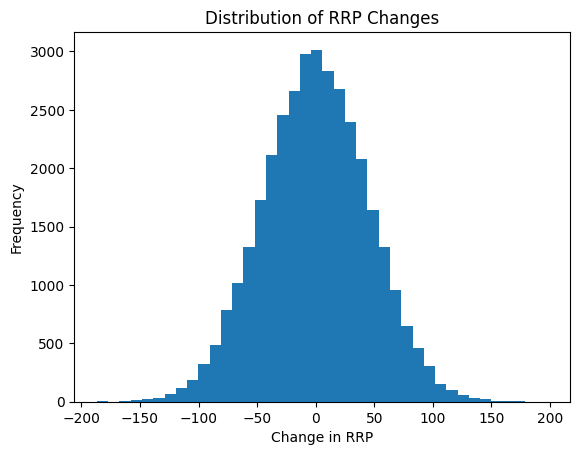

In [28]:
plt.hist(df["change_rrp"], bins=40)
plt.xlabel("Change in RRP")
plt.ylabel("Frequency")
plt.title("Distribution of RRP Changes")

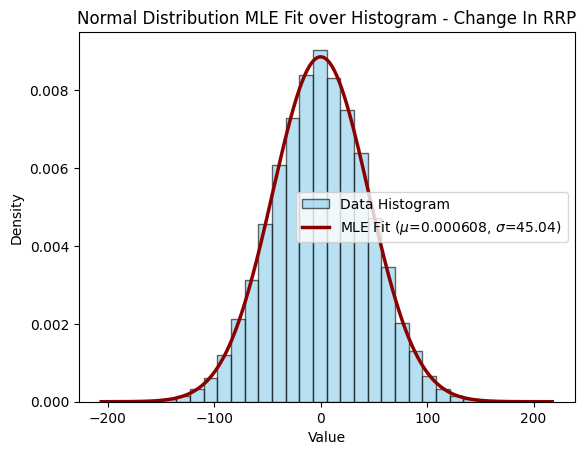

In [31]:
df_clean_rrp = df.drop_nulls(subset=["change_rrp"])

mu, sigma = stats.norm.fit(df_clean_rrp["change_rrp"])

plt.hist(df_clean_rrp["change_rrp"], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')

x_min, x_max = plt.xlim()
x_axis = np.linspace(x_min, x_max, 1000)
fitted_pdf_norm = stats.norm.pdf(x_axis, mu, sigma)

plt.plot(x_axis, fitted_pdf_norm, color='darkred', linewidth=2.5, label=fr'MLE Fit ($\mu$={mu:.6f}, $\sigma$={sigma:.2f})')
plt.title('Normal Distribution MLE Fit over Histogram - Change In RRP')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

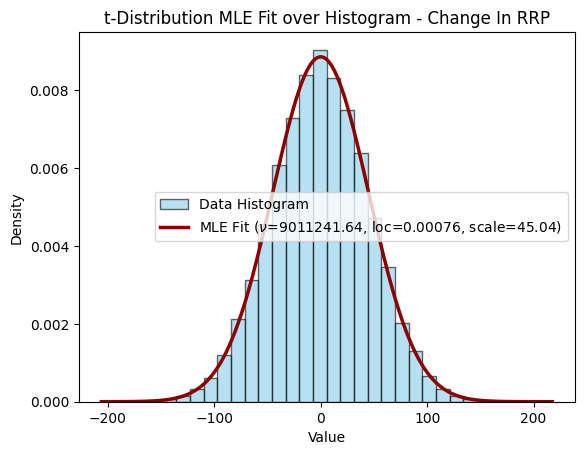

In [32]:
nu, loc, scale = stats.t.fit(df_clean_rrp["change_rrp"])

plt.hist(df_clean_rrp["change_rrp"], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')

x_min, x_max = plt.xlim()
x_axis = np.linspace(x_min, x_max, 1000)
fitted_pdf_t = stats.t.pdf(x_axis, nu, loc, scale)

plt.plot(x_axis, fitted_pdf_t, color='darkred', linewidth=2.5, label=fr'MLE Fit ($\nu$={nu:.2f}, loc={loc:.5f}, scale={scale:.2f})')

# 4. Final adjustments
plt.title('t-Distribution MLE Fit over Histogram - Change In RRP')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

## we see from high nu value essentially identical to normal distribution

In [33]:
stats.skew(df_clean_rrp["change_rrp"]), stats.kurtosis(df_clean_rrp["change_rrp"])

(np.float64(-0.008957614396617908), np.float64(-0.015924741772002537))

In [34]:
df["change_rrp"].describe()

statistic,value
str,f64
"""count""",35038.0
"""null_count""",1.0
"""mean""",0.000608
"""std""",45.038312
"""min""",-186.76
"""25%""",-30.5
"""50%""",-0.02
"""75%""",30.78
"""max""",198.24


##### Volatility of prices

In [35]:
## prices vol 

In [38]:
from arch import arch_model

# alpha - shock sensitivity
# beta - memory persistence


model_change_rrp = arch_model(df_clean_rrp["change_rrp"], vol='Garch', p=1, q=1, dist='t')  
fit_change_rrp = model_change_rrp.fit(disp='off')
print(fit_change_rrp.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -182374.
Distribution:      Standardized Student's t   AIC:                           364759.
Method:                  Maximum Likelihood   BIC:                           364801.
                                              No. Observations:                35038
Date:                      Wed, Jul 01 2026   Df Residuals:                    35037
Time:                              12:39:39   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0

Note the p values for alpha and beta just show that the results and hence conclusions from the alpha and beta values are statistically significant. 

We notice from the table that electricity prices dont experience the same volatility drag that might be found in the stockmarket (evidenced by very low beta value). Here the volatility is not sticky, and market memory is short. The volatility in the price is driven by physical shocks (high alpha value). 

In [40]:
df_clean_rrp = df_clean_rrp.with_columns([
    pl.Series("GARCH_volatility", fit_change_rrp.conditional_volatility)
])

Text(0.5, 1.0, 'Distribution of GARCH Volatility (from change_rrp)')

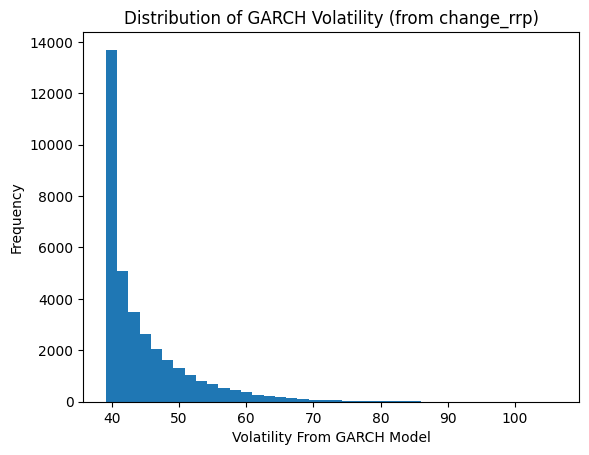

In [41]:
plt.hist(df_clean_rrp["GARCH_volatility"], bins=40)
plt.xlabel("Volatility From GARCH Model")
plt.ylabel("Frequency")
plt.title("Distribution of GARCH Volatility (from change_rrp)")

## CONSIDERING BASIC SIMULATIONS

##### Regime based strategy

In [42]:
import electricity_backtester

class ForecastingRegimeStrategy(electricity_backtester.BaseStrategy):
    def __init__(self, filtered_probs, transition_matrix, state_order, 
                 regime_models, feature_matrix, feature_names,
                 charge_threshold=0.05, discharge_threshold=0.05, efficiency=0.88):


        # filtered_probs: out of sample filtered marginal probabilities to avoid look-ahead bias
        # transition_matrix: fitted transition matrix from MarkovRegression model
        # state_order: sorted state indices from lowest to highest variance
        # regime_models: dictionary mapping state integer keys to trained GBDT expert models
        # feature_matrix: 2d array of features aligned with the backtest loop
        # feature_names: list of feature names corresponding to the columns of feature_matrix

        super().__init__()
        self.filtered_probs = np.array(filtered_probs)
        self.transition_matrix = np.array(transition_matrix)
        self.feature_matrix = feature_matrix  
        self.feature_names = feature_names
        self.models = regime_models
        self.efficiency = efficiency
        
        self.charge_state_idx = state_order[0]     # regime 0: low/negative pricing
        self.hold_state_idx = state_order[1]       # regime 1: intermediate pricing
        self.discharge_state_idx = state_order[2]  # regime 2: higher pricing
        
        # risk sensitivity thresholds
        self.charge_threshold = charge_threshold
        self.discharge_threshold = discharge_threshold
        
        # internal accounting tracker to enforce thermodynamic break-even thresholds
        self.last_charge_price = None


    def _predict_next_price(self, next_regime_idx, current_step_idx):
        
        # evaluates the specific GBDT expert for a targeted regime state
        if next_regime_idx in self.models:
    
            row = self.feature_matrix[current_step_idx : current_step_idx + 1]
            return self.models[next_regime_idx].predict(row)[0]
        
        return None


    def compute_action(self, idx: int, current_price: float) -> float:

        # safety check to ensure index does not overrun available probability rows
        if idx >= len(self.filtered_probs):
            return 0.0

        # Extract current filtered probability vector slice
        p_t = self.filtered_probs[idx]
        
        # forward propagate probability distribution to step t+1 via transition matrix
        p_next = np.dot(self.transition_matrix, p_t)
        
        prob_of_negative_drop = p_next[self.charge_state_idx]
        prob_of_peak_spike = p_next[self.discharge_state_idx]
        
        # evaluate charging opportunity
        if prob_of_negative_drop > self.charge_threshold:

            expected_charge_price = self._predict_next_price(self.charge_state_idx, idx)
            
            # if the GBDT model confirms a a low/negative pricing window - charge
            if expected_charge_price is not None and expected_charge_price <= current_price:
                self.last_charge_price = current_price
                return -1.0
                
        # evaluate discharging opportunity
        elif prob_of_peak_spike > self.discharge_threshold:

            predicted_discharge_price = self._predict_next_price(self.discharge_state_idx, idx)
            
            if predicted_discharge_price is not None:
                if self.last_charge_price is not None:

                    # enforcing physical round-trip break-even efficiency constraints
                    break_even_hurdle = self.last_charge_price / self.efficiency
                    
                    # only discharge if both current market and forecasted market clear our total asset tax
                    if predicted_discharge_price > break_even_hurdle and current_price > break_even_hurdle:

                        return 1.0
                else:
                    # default safety floor fallback if asset starts fully charged without history
                    if current_price > 85.0: 
                        return 1.0
                        
        return 0.0

In [43]:
# define slice windows safely based on your out-of-sample test array size
slice_length = min(2016, len(X_test)) 
df_synthetic_world = df_clean.slice(train_size, slice_length)

X_stress = X_test[:slice_length]

# extract filtered probabilities and automatically correct the shape if transposed
filtered_probs_all = results_30min.filtered_marginal_probabilities


## DELETE??
# if filtered_probs_all.shape[1] != 3:  # If shape comes out as (3, nobs) instead of (nobs, 3)
#     filtered_probs_all = filtered_probs_all.T


filtered_probs_slice = filtered_probs_all[train_size : train_size + slice_length]
transition_mat = results_30min.model.regime_transition_matrix(results_30min.params)[..., 0]

# 6. FIX: Dynamically build state_order to map low, baseline, and spike states
# (Prevents index-swapping errors if your model variables re-order on execution)
regimes_train_check = np.argmax(filtered_probs_all[:train_size], axis=1)
regime_means = []

for i in range(3):

    mask = (regimes_train_check == i)
    if np.any(mask):

        regime_means.append(df_clean["RRP"][:train_size].filter(mask).mean())
    else:

        regime_means.append(i * 50.0) # fallback default

state_order = np.argsort(regime_means)


battery_asset = electricity_backtester.BatteryAsset(capacity_mwh=2.0, max_power_mw=1.0, efficiency=0.88)

regime_strategy = ForecastingRegimeStrategy(
    filtered_probs=filtered_probs_slice,
    transition_matrix=transition_mat,               
    state_order=state_order,                         
    regime_models=regime_models,
    feature_matrix=X_stress,
    feature_names=feature_names,
    charge_threshold=0.02, # high sensitivity to capture rare charging price drops
    discharge_threshold=0.15, # somewhat conservative barrier to preserve capacity for peak spikes
    efficiency=0.88
)


backtest_engine = electricity_backtester.EnergyStorageBacktester(
    df=df_synthetic_world,
    battery=battery_asset,
    strategy=regime_strategy
)

results_df = backtest_engine.run()

In [44]:
print(results_df.select(["RRP", "Sim_Action", "Sim_SoC_MWh", "Sim_PnL"]).head(10))

shape: (10, 4)
┌────────┬────────────┬─────────────┬─────────┐
│ RRP    ┆ Sim_Action ┆ Sim_SoC_MWh ┆ Sim_PnL │
│ ---    ┆ ---        ┆ ---         ┆ ---     │
│ f64    ┆ str        ┆ f64         ┆ f64     │
╞════════╪════════════╪═════════════╪═════════╡
│ 67.24  ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 115.54 ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 85.13  ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 116.91 ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 78.69  ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 122.34 ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 96.81  ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 85.85  ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 42.25  ┆ HOLD       ┆ 0.0         ┆ 0.0     │
│ 56.65  ┆ HOLD       ┆ 0.0         ┆ 0.0     │
└────────┴────────────┴─────────────┴─────────┘


                  PERFORMANCE REPORT                    
Net Portfolio Revenue     : $-37.33
Maximum Peak-to-Trough DD : $65.90
Equivalent Full Cycles    : 3.01 cycles
---------------------------------------------------------
Total Operational Actions :
  - CHARGE Events         : 82
  - DISCHARGE Events      : 77
  - HOLD Events           : 1857


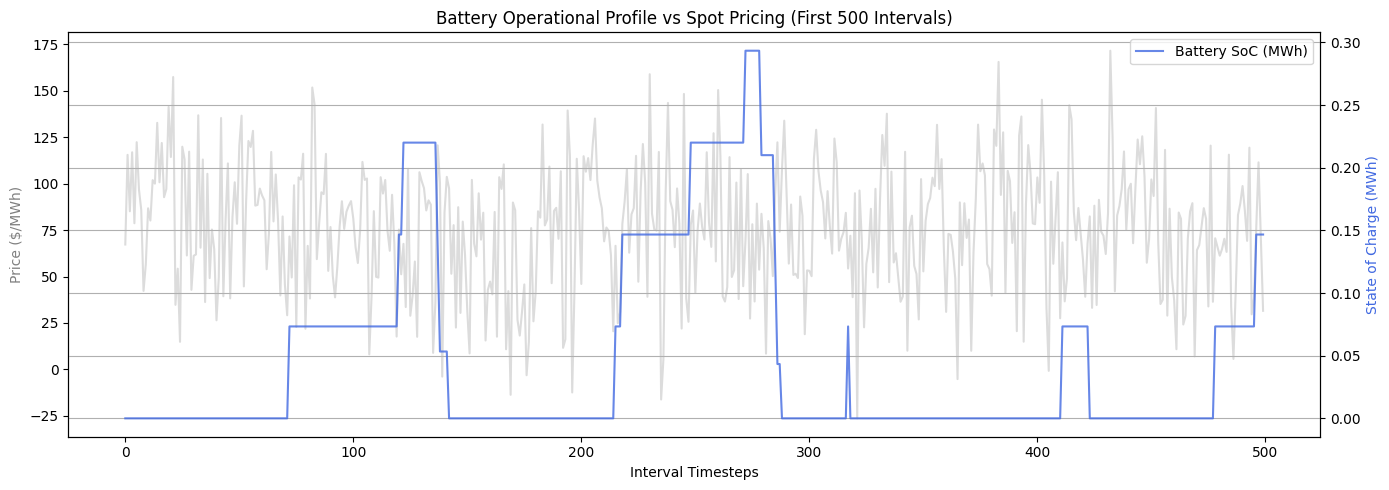

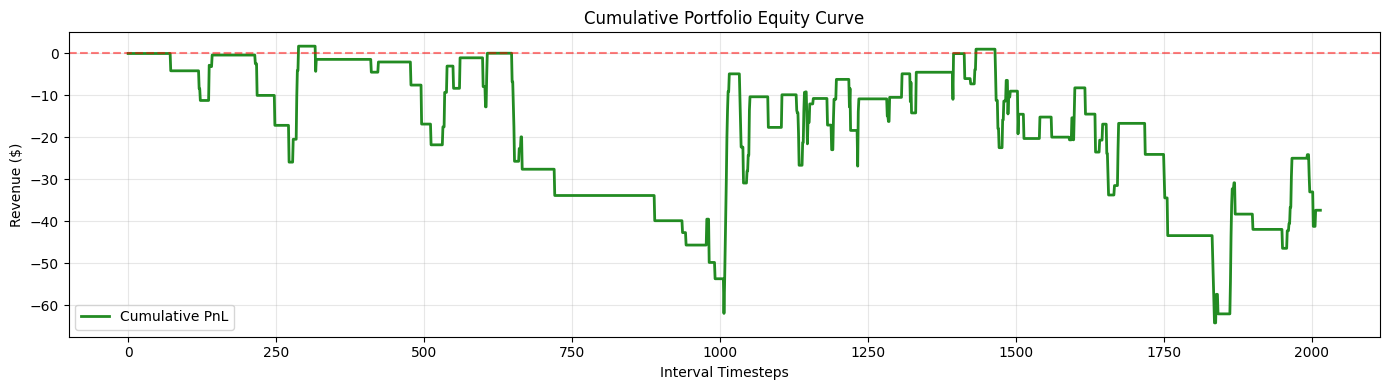

In [45]:
regime_reporter = electricity_backtester.BacktestReporter(results_df=results_df, battery_capacity_mwh=2.0)

regime_reporter.print_summary_metrics()
regime_reporter.plot_battery_state()
regime_reporter.plot_pnl_trajectory()

##### Simple threshold strategy

In [46]:
import electricity_backtester

class PriceThresholdStrategy(electricity_backtester.BaseStrategy):

    def __init__(self):
        super().__init__()

    def compute_action(self, idx: int, current_price: float) -> float:
        # on the very first row there's no previous price, so hold
        if idx == 0:
            return 0.0 # HOLD

        last_price = self.prices[idx - 1] if hasattr(self, 'prices') else current_price

        if last_price <= 0:
            return -1.0 # CHARGE (max rate)
        elif last_price > 70:
            return 1.0 # DISCHARGE (max rate)
        else:
            return 0.0 # HOLD

In [47]:
df_5min = pl.read_csv("PRICE_AND_DEMAND_202406_SA1.csv")
df_5min = df_5min.with_columns([
    pl.col("RRP").shift(-1).alias("target_next_RRP")
])
df_5min = df_5min.drop_nulls(subset=["target_next_RRP"])

In [48]:
simple_strategy = PriceThresholdStrategy()

battery_forecast = electricity_backtester.BatteryAsset(capacity_mwh=2.0, max_power_mw=1.0, efficiency=0.90)

simple_engine = electricity_backtester.EnergyStorageBacktester(
    df=df_5min,
    battery=battery_forecast,
    strategy=simple_strategy
)

simple_results_df = simple_engine.run()



                  PERFORMANCE REPORT                    
Net Portfolio Revenue     : $4,552.59
Maximum Peak-to-Trough DD : $43.31
Equivalent Full Cycles    : 12.26 cycles
---------------------------------------------------------
Total Operational Actions :
  - CHARGE Events         : 414
  - DISCHARGE Events      : 297
  - HOLD Events           : 7928


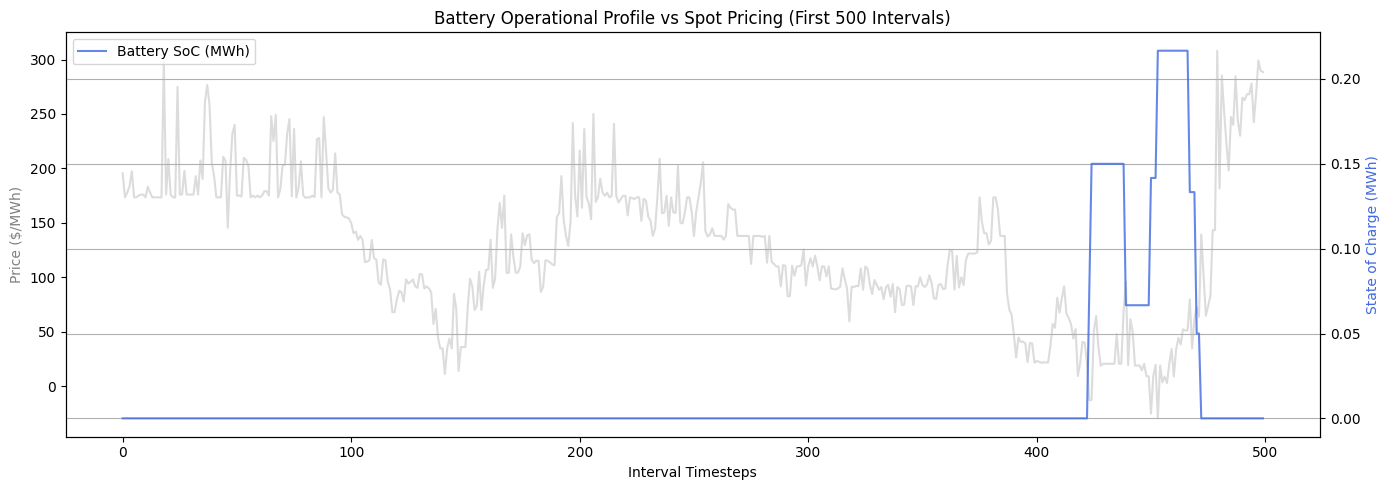

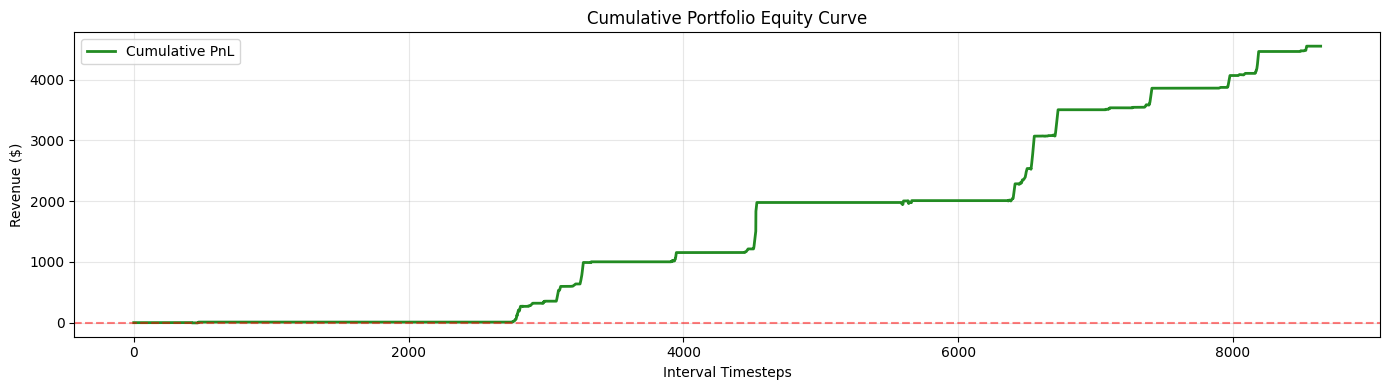

In [49]:
threshold_reporter = electricity_backtester.BacktestReporter(
    results_df=simple_results_df,
    battery_capacity_mwh=2.0
)
threshold_reporter.print_summary_metrics()
threshold_reporter.plot_battery_state()
threshold_reporter.plot_pnl_trajectory()

In [50]:
# considering the next period 
next_price_after_negative = df_5min.filter(pl.col("RRP") <= 0)["target_next_RRP"]
print(f"Average price immediately AFTER a negative (<0) event: ${next_price_after_negative.mean():.2f}/MWh")

next_price_after_spike = df_5min.filter(pl.col("RRP") > 70)["target_next_RRP"]
print(f"Average price immediately AFTER a spike (>70) event: ${next_price_after_spike.mean():.2f}/MWh")

Average price immediately AFTER a negative (<0) event: $-24.51/MWh
Average price immediately AFTER a spike (>70) event: $214.36/MWh
